In [44]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy
from sklearn.model_selection import KFold

phot_data = pd.read_csv("string_phot_rat_data.csv")
data = phot_data.drop(columns=['percentage_x', 'x_reach_centered', 'y_reach_centered'])
data = data.dropna()

data['rat'].unique()
# one hot encode rat
encode_data = data.copy()
rat6 = data['rat'] == 6
rat25 = data['rat'] == 25
encode_data['rat6'] = rat6.astype(int)
encode_data['rat25'] = rat25.astype(int)
encode_data = encode_data.drop(columns='rat')

In [32]:
def linear_regression_gradient_descent(X, y):
    if len(X.shape) > 1:
        n_samples, n_features = X.shape
        weights = numpy.zeros(n_features)
    else:
        n_samples = X.size
        n_features = 1
        weights = 0
    # implement gradient descent
    # set initial weights and biases
    bias = 1
    learning_rate = 0.001
    epochs = 10000

    # fit the model
    for epoch in range(epochs):
        # calculate predicted y
        y_predicted = numpy.dot(X, weights) + bias
        # get the error for weights and bias
        diff_w = (1/n_samples) * numpy.dot(X.T, (y_predicted - y))
        diff_b = (1/n_samples) * numpy.sum(y_predicted - y)  

        # update weights and biases
        weights -= learning_rate*diff_w
        bias -= learning_rate*diff_b
    return weights, bias

In [ ]:
def calculate_RSE(y_pred, y, n_sample, n_params):
    rss = (y_pred - y)**2
    rse = numpy.sqrt(rss/(n_sample-n_params-1))
    return rse

def calculate_SE(x, y_pred, y, n_samples, n_params):
    rse = calculate_RSE(y_pred, y, n_samples, n_params)
    se = rse/numpy.sqrt((x-numpy.mean(x))**2)
    return se

def calculate_SE_intercept():
    return

def calculate_R2():
    return

def calculate_F():
    return

def calculate_tstat(x, y_pred, y, n_samples, n_params, B):
    se = calculate_SE(x, y_pred, y, n_samples, n_params)
    tstat = B/se
    return tstat

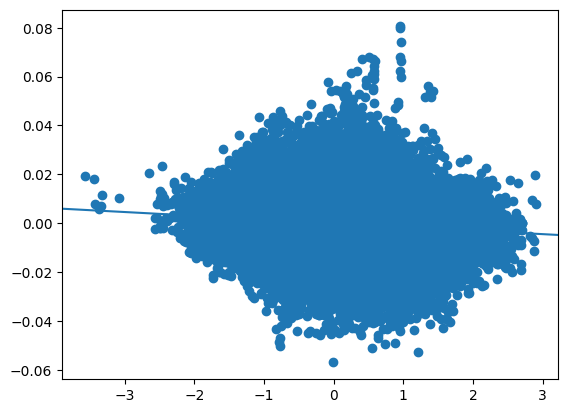

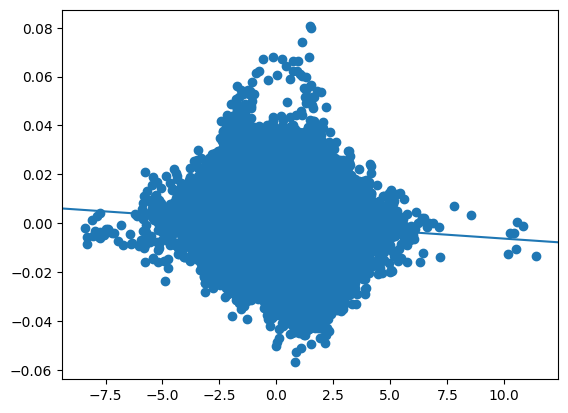

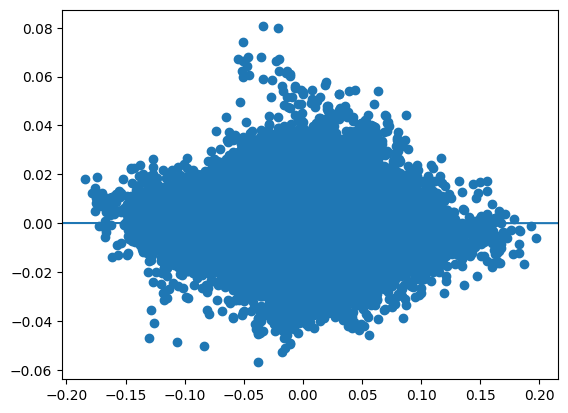

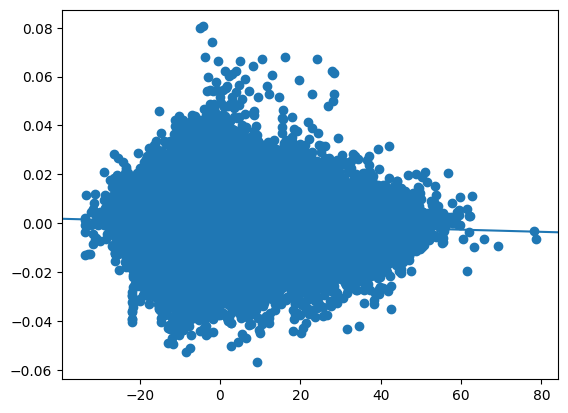

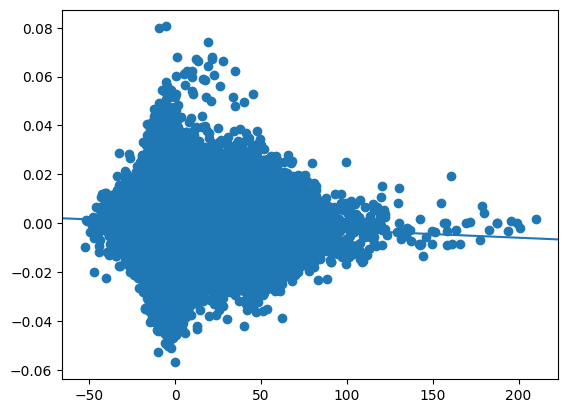

In [ ]:
X_df = encode_data.drop(columns=['df_centered'])
X = X_df.to_numpy()
y = encode_data['df_centered']





In [ ]:
def simple_reg_for_each_parameter(X, y):    
    simple_reg_dict = {}
    # avoids the rat classifications
    for param in X_df.columns[:-2]:
        plt.figure()
        plt.scatter(X_df[param], y)
        plt.axline(xy1=(0,bias), slope=weight)
    
    simple_reg = pd.DataFrame(simple_reg_dict)


In [ ]:
def k_fold_cross_val(X, y, n_samples, n_params):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    kf.split(X)
    weights = []
    biases = []
    for testIX, trainIX in kf.split(X):
        train_X, test_X = X[trainIX], X[testIX]
        train_y, test_y = y[trainIX], y[testIX]
        weight, bias = linear_regression_gradient_descent(X_df[param].to_numpy(),y)
        y_pred = numpy.dot(test_X, weight) + bias
        se = calculate_SE(X, y_pred, y, n_samples, n_params)
        weights.append(weight)
        biases.append(weight)

        
        

In [40]:
simple_reg = pd.DataFrame(simple_reg_dict, index=('weight', 'bias'))
simple_reg.head()

,x_pos_centered,y_pos_centered,effort_centered,rot_centered,paw_vel_centered
weight,-0.001509,-0.000636,-0.000113,-0.000045,-0.000030
bias,0.000047,0.000047,0.000047,0.000047,0.000048


In [31]:
weights = 0
numpy.dot(X[:,1], weights)

array([0., 0., 0., ..., 0., 0., 0.], shape=(133405,))